# Bayesian Uncertainty Minimization


In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

sys.path.append("../..")
import gpder 
from gpder import UncertaintyOptimization
from gpder.bayes.minimizers import hybrid_minimizer

from utils import plot_gpr_evolution, plot_gpr_iterloss

In [2]:
import sys 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sys.path.append("../..")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware

try:
    import uproot
except:
    print("uproot must be installed to run this demo.")

In [3]:
f = uproot.open("./three_jets.root")
tree = f['tnt']

njets = np.array(tree['nj'])
njets_cut = np.where(njets < 4)

j1_threeM = np.stack((np.array(tree['j1_pt'])[njets_cut],
                      np.array(tree['j1_eta'])[njets_cut],
                      np.array(tree['j1_phi'])[njets_cut]), axis=1)

j2_threeM = np.stack((np.array(tree['j2_pt'])[njets_cut],
                      np.array(tree['j2_eta'])[njets_cut],
                      np.array(tree['j2_phi'])[njets_cut]), axis=1)

j3_threeM = np.stack((np.array(tree['j3_pt'])[njets_cut],
                      np.array(tree['j3_eta'])[njets_cut],
                      np.array(tree['j3_phi'])[njets_cut]), axis=1)

f.close()

In [4]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))

In [5]:
def Eff_MET50_sigmoid(J_scale, j_scale, 
                      j1_threeM=j1_threeM, 
                      j2_threeM=j2_threeM, 
                      j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            count_met += sigmoid(-(met-50.0))

    return count_met / count_pTcut

### Regular GPR

In [6]:
# -- training points -- # 
nu_a_train = [0.9, 1.0, 1.0, 1.0, 1.1]
nu_j_train = [1.0, 0.9, 1.0, 1.1, 1.0]
X_train = np.vstack((nu_a_train, nu_j_train)).T

y_train = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                      X_train[i][1]) for i in range(len(X_train))])
y_train_sig = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                          X_train[i][1]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.7
X_upper = 1.3
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])
y_test_sig = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])

In [9]:
def minimizer(fun, bounds):
    return hybrid_minimizer(fun, bounds, 
                            N_rand=10, 
                            N_brute=3)

| Iter | J_scale   | j_scale   | Target    | Uncert    | MSE val   | Uncert val|
| 1    | 0.900000  | 1.000000  | 0.580745  | 0.972420  | 0.047238  | 2.292281  |
| 2    | 1.000000  | 0.900000  | 0.787183  | 0.972420  | 0.047238  | 2.292281  |
| 3    | 1.000000  | 1.000000  | 0.780826  | 0.972420  | 0.047238  | 2.292281  |
| 4    | 1.000000  | 1.100000  | 0.661358  | 0.972420  | 0.047238  | 2.292281  |
| 5    | 1.100000  | 1.000000  | 0.834261  | 0.972420  | 0.047238  | 2.292281  |
| 6    | 0.711782  | 0.749254  | 0.489718  | 3.460298  | 0.121707  | 0.664980  |
| 7    | 1.098981  | 1.008114  | 0.841417  | 4.257494  | 0.124088  | 0.493372  |
| 8    | 1.098324  | 1.035541  | 0.840801  | 1.823791  | 0.016273  | 1.524758  |
| 9    | 1.267393  | 0.700000  | 0.295783  | 1.777238  | 0.019388  | 1.079712  |
| 10   | 0.740614  | 1.296089  | 0.001625  | 1.529443  | 0.016358  | 0.853779  |
| 11   | 1.260836  | 1.290527  | 0.818856  | 2.045432  | 0.009827  | 0.543361  |
| 12   | 1.299673  | 1.07532

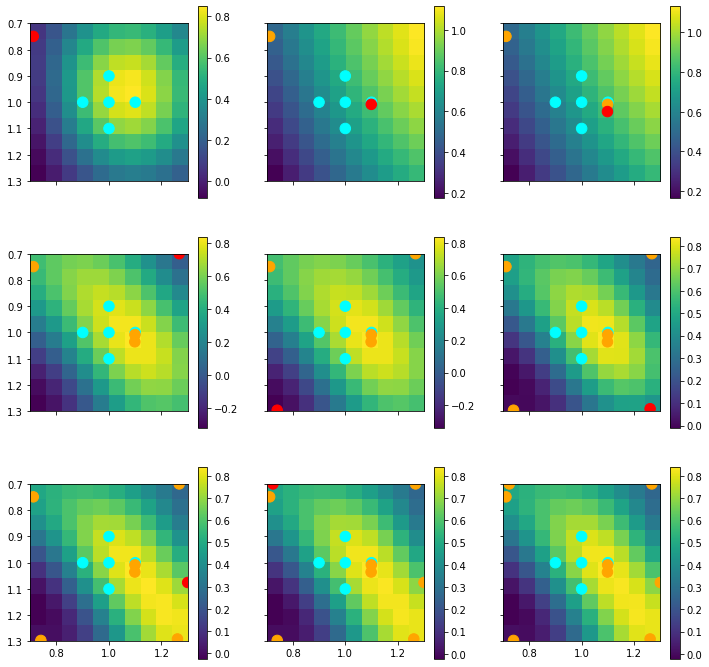

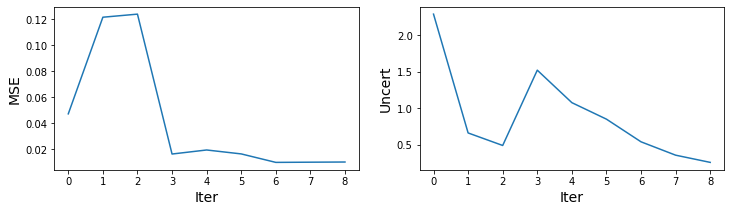

In [10]:
bayes = UncertaintyOptimization(fun=Eff_MET50_sigmoid,
                                ignore_convergence_warnings=True,
                                verbose=True,
                                param_bounds={'J_scale': (0.7, 1.3), 
                                              'j_scale': (0.7, 1.3)},
                                random_state=123)
bayes.minimize_uncertainty(params_train=X_train,
                           minimizer=minimizer,
                           gamma=0,
                           params_val=X_test,
                           niters=8,
                           minimizer_restarts=1,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes), X_lower=0.7, X_upper=1.3)
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))

### With derivatives

In [11]:
def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [12]:
def dEff_MET50_sigmoid(J_scale, j_scale, 
              j1_threeM=j1_threeM, j2_threeM=j2_threeM, j3_threeM=j3_threeM):
    dmet_dj1 = 0
    dmet_dj2j3 = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            dsig = -dsigmoid(-(met-50.0))
            dmet = 0.5 / met

            # wrt J_scale 
            dj1  = -2*met_x*j1_threeM[i, 0] * np.cos(j1_threeM[i, 2]) / J_scale**2
            dj1 += -2*met_y*j1_threeM[i, 0] * np.sin(j1_threeM[i, 2]) / J_scale**2
            # wrt j_scale
            dj2j3  = -2*met_x*j2_threeM[i, 0] * np.cos(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_x*j3_threeM[i, 0] * np.cos(j3_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j2_threeM[i, 0] * np.sin(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j3_threeM[i, 0] * np.sin(j3_threeM[i, 2]) / j_scale**2

            dmet_dj1   += dsig * dmet * dj1
            dmet_dj2j3 += dsig * dmet * dj2j3

    return [dmet_dj1 / count_pTcut, dmet_dj2j3 / count_pTcut]


In [13]:
dX_train = X_train
dy_train_sig = np.array([dEff_MET50_sigmoid(dX_train[i][0], 
                                            dX_train[i][1]) for i in range(len(dX_train))])

In [14]:
def minimizer(fun, bounds):
    return hybrid_minimizer(fun, bounds, 
                            N_rand=10, 
                            N_brute=3)

| Iter | J_scale   | j_scale   | Target    | Uncert    | MSE val   | Uncert val|
| 1    | 0.900000  | 1.000000  | 0.580745  | 51.072517 | 0.030892  | 2.659504  |
| 2    | 1.000000  | 0.900000  | 0.787183  | 51.072517 | 0.030892  | 2.659504  |
| 3    | 1.000000  | 1.000000  | 0.780826  | 51.072517 | 0.030892  | 2.659504  |
| 4    | 1.000000  | 1.100000  | 0.661358  | 51.072517 | 0.030892  | 2.659504  |
| 5    | 1.100000  | 1.000000  | 0.834261  | 51.072517 | 0.030892  | 2.659504  |
| 6    | 0.700000  | 1.300000  | 0.001049  | 40.801150 | 0.009213  | 1.920522  |
| 7    | 1.307625  | 1.300000  | 0.841275  | 49.417679 | 0.008270  | 1.205053  |
| 8    | 0.981224  | 0.763816  | 0.429309  | 70.669756 | 0.014697  | 1.031954  |
| 9    | 1.300000  | 0.700000  | 0.278706  | 78.180134 | 0.003375  | 0.676771  |
| 10   | 0.736195  | 0.773063  | 0.511911  | 80.764861 | 0.003246  | 0.271354  |
| 11   | 1.193004  | 0.700000  | 0.242642  | 81.601750 | 0.002919  | 0.324154  |
| 12   | 0.700000  | 1.09243

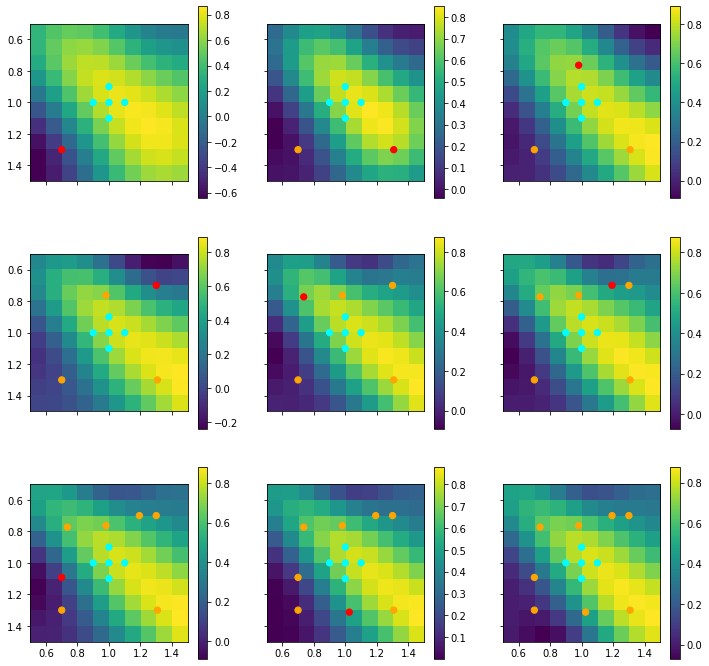

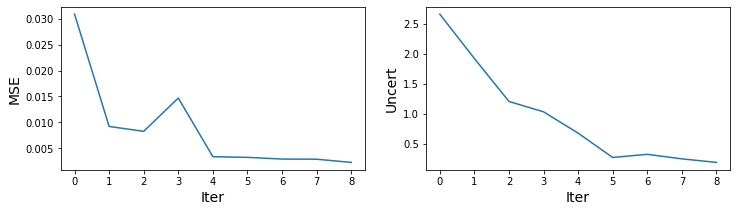

In [17]:
bayes = UncertaintyOptimization(fun=Eff_MET50_sigmoid,
                                dfun=dEff_MET50_sigmoid,
                                ignore_convergence_warnings=True,
                                verbose=True,
                                param_bounds={'J_scale': (0.7, 1.3), 
                                              'j_scale': (0.7, 1.3)},
                                random_state=123)
bayes.minimize_uncertainty(params_train=X_train,
                           minimizer=minimizer,
                           gamma=0,
                           params_val=X_test,
                           niters=8,
                           minimizer_restarts=1,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes), X_lower=0.5, X_upper=1.5)
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))

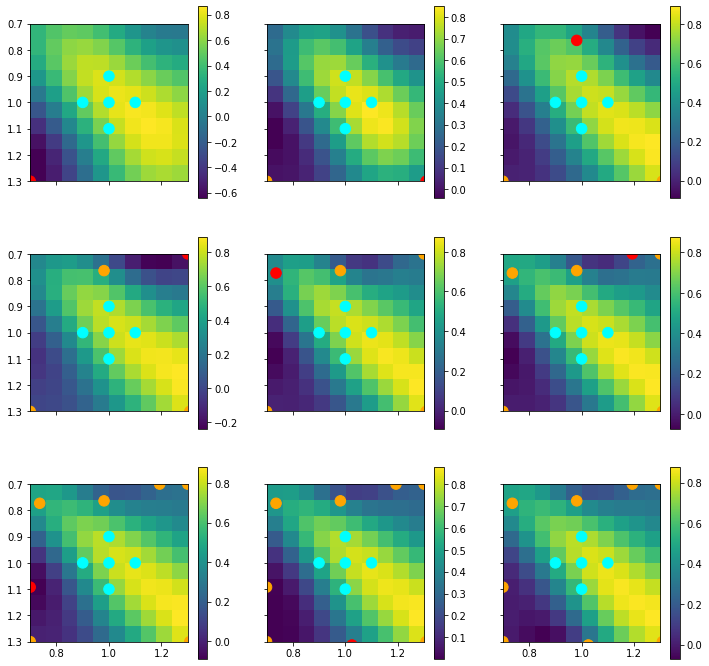

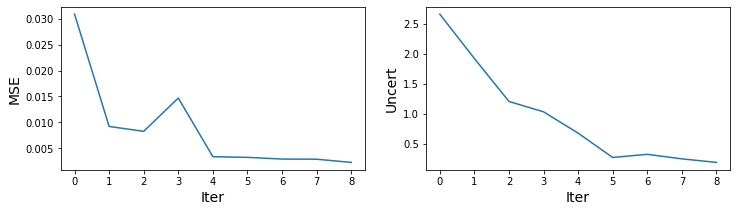

In [18]:
plot_gpr_evolution(bayes=copy.deepcopy(bayes), X_lower=0.7, X_upper=1.3)
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))

| Iter | J_scale   | j_scale   | Target    | Uncert    | MSE val   | Uncert val|
| 1    | 0.900000  | 1.000000  | 0.580745  | 51.072517 | 0.030892  | 2.659504  |
| 2    | 1.000000  | 0.900000  | 0.787183  | 51.072517 | 0.030892  | 2.659504  |
| 3    | 1.000000  | 1.000000  | 0.780826  | 51.072517 | 0.030892  | 2.659504  |
| 4    | 1.000000  | 1.100000  | 0.661358  | 51.072517 | 0.030892  | 2.659504  |
| 5    | 1.100000  | 1.000000  | 0.834261  | 51.072517 | 0.030892  | 2.659504  |
| 6    | 0.533479  | 0.500000  | 0.160617  | 175.525496| 0.074586  | 3.368196  |
| 7    | 0.502093  | 1.452423  | 0.000000  | 129.408781| 0.021631  | 3.004993  |
| 8    | 1.482748  | 1.488277  | 0.868193  | 134.549258| 0.020818  | 2.087924  |
| 9    | 1.498204  | 0.928837  | 0.250852  | 137.134828| 0.017636  | 1.413710  |
| 10   | 1.515547  | 0.508134  | 0.000000  | 131.390841| 0.016867  | 1.232205  |
| 11   | 1.522561  | 1.294434  | 0.780110  | 142.749147| 0.015443  | 1.247442  |
| 12   | 0.995401  | 1.50000

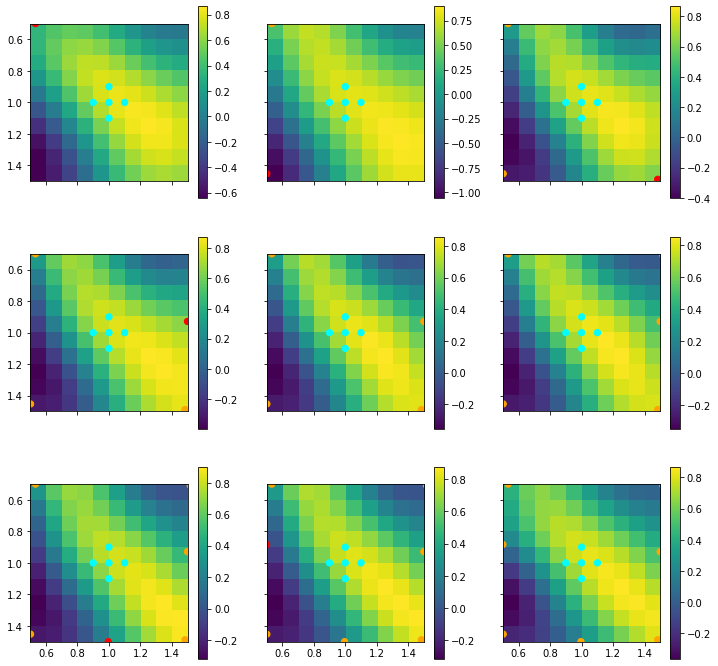

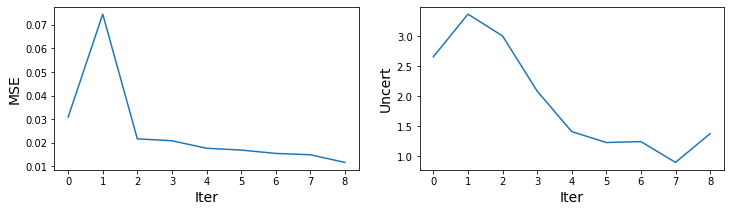

In [16]:
bayes = UncertaintyOptimization(fun=Eff_MET50_sigmoid,
                                dfun=dEff_MET50_sigmoid,
                                ignore_convergence_warnings=True,
                                verbose=True,
                                param_bounds={'J_scale': (0.5, 1.5), 
                                              'j_scale': (0.5, 1.5)},
                                random_state=123)
bayes.minimize_uncertainty(params_train=X_train,
                           minimizer=minimizer,
                           gamma=0,
                           params_val=X_test,
                           niters=8,
                           minimizer_restarts=1,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes), X_lower=0.5, X_upper=1.5)
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))